# 02 — Preprocessing

Margin removal, pad to square, resize, normalize. Then re-running the leakage
controls from notebook 01 on the cropped data to check whether cropping
actually removed the background shortcut.

**Order is important:** crop → pad → resize → normalize. 

From notebook 01:
- Sizes vary 150–1338px, ~20% non-square → pad, don't stretch
- Mixed channel modes (RGB / L / RGBA) → convert to `L` early
- Border-only classification hits 0.634 vs 0.262 baseline → cropping is
  leakage mitigation, and must be re-measured
- `notumor` is a different pulse sequence → cropping will NOT fix that

## 1. Setup

In [1]:
import csv, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

with open("data/manifest.csv") as f:
    rows = list(csv.DictReader(f))

records = [(r["split"], r["class"], Path(r["path"])) for r in rows]
CLASSES = sorted({r["class"] for r in rows})
SPLITS = ["Training", "Testing"]
meta = {p: (s, c) for s, c, p in records}

print(f"{len(records)} records, classes: {CLASSES}")

7200 records, classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. The crop function

Standard contour-based approach:

1. Blur to suppress noise that would fragment the threshold
2. Otsu threshold — adaptive, since intensity ranges vary across sources
(otsu thresholding separates an image into different classes of foreground and background 
by analyzing all pixel intensities from the grayscale of the image and then minimizes
the variance WITHIN each class and maximizes variance BETWEEN the classes)
3. Erode then dilate to remove speckle without shrinking the brain
4. Take the largest contour which is the head
5. Crop to its bounding box with a small padding margin

**Important:** this is not skull-stripping. In sagittal views the largest contour is
the entire head including face and neck. This removes black margins and
watermark bars, not non-brain tissue.

In [2]:
def crop_margins(img_gray, pad=4, min_area_frac=0.05, debug=False):
    """
    Crop an image to the bounding box of its largest bright region.

    img_gray       : 2-D uint8 array
    pad            : pixels of margin to keep around the detected region
    min_area_frac  : if the detected region is smaller than this fraction of
                     the image, treat detection as failed and return the
                     original. This guards against thresholding onto a watermark
                     or a scanner annotation instead of the head
    debug          : also return the intermediate mask for inspection

    Returns the cropped array (and mask if debug=True).
    """
    # Blur first: raw MRI has fine noise that fragments the threshold into
    # hundreds of tiny contours, which makes "largest contour" unreliable.
    # using GuassianBlur to reduce noise 
    blurred = cv2.GaussianBlur(img_gray, (5, 5), 0)

    # Otsu picks the threshold from the image's own histogram. A fixed value
    # would fail here because notumor images are much brighter overall than
    # the tumor classes which is why we need automatic thresholding.
    _, thresh = cv2.threshold(blurred, 0, 255,
                              cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Erode kills isolated speckle; dilate restores the head to roughly its
    # original extent. Same iteration count so the net size change is ~zero.
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    # finding contours in the thresholded image
    # contours are continuous curves or lines connecting all the points along the boundary of an object
    # RETR_EXTERNAL retrieves only the outermost contours
    # CHAIN_APPROX_SIMPLE compresses horizontal, vertical, and diagonal segments
    # and leaves only their end points which helps in reducing the number of points in the contour and helps in faster processing 
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return (img_gray, thresh) if debug else img_gray

    # finding the largest contour by area
    largest = max(contours, key=cv2.contourArea)
    # getting the bounding rectangle of the largest contour 
    # which is the smallest rectangle that can contain the contour with x,y,w,h 
    # x,y is the coordinate of the top left corner of the rectangle and w,h is the width and height of the rectangle
    x, y, w, h = cv2.boundingRect(largest)

    # Sanity check: a tiny box means we locked onto an annotation, not a head.
    if (w * h) < min_area_frac * img_gray.size:
        return (img_gray, thresh) if debug else img_gray

    # Clip padding to image bounds so we never index outside the array.
    H, W = img_gray.shape
    x0, y0 = max(0, x - pad), max(0, y - pad)
    x1, y1 = min(W, x + w + pad), min(H, y + h + pad)

    # cropping the image to the bounding rectangle
    out = img_gray[y0:y1, x0:x1]
    return (out, thresh) if debug else out

## 3. Validate it visually

Looking at real images before trusting the function on
7,200. Failure mode to watch for: a bright watermark bar or burned-in text
becoming the largest contour, so you crop to the annotation instead of the head.

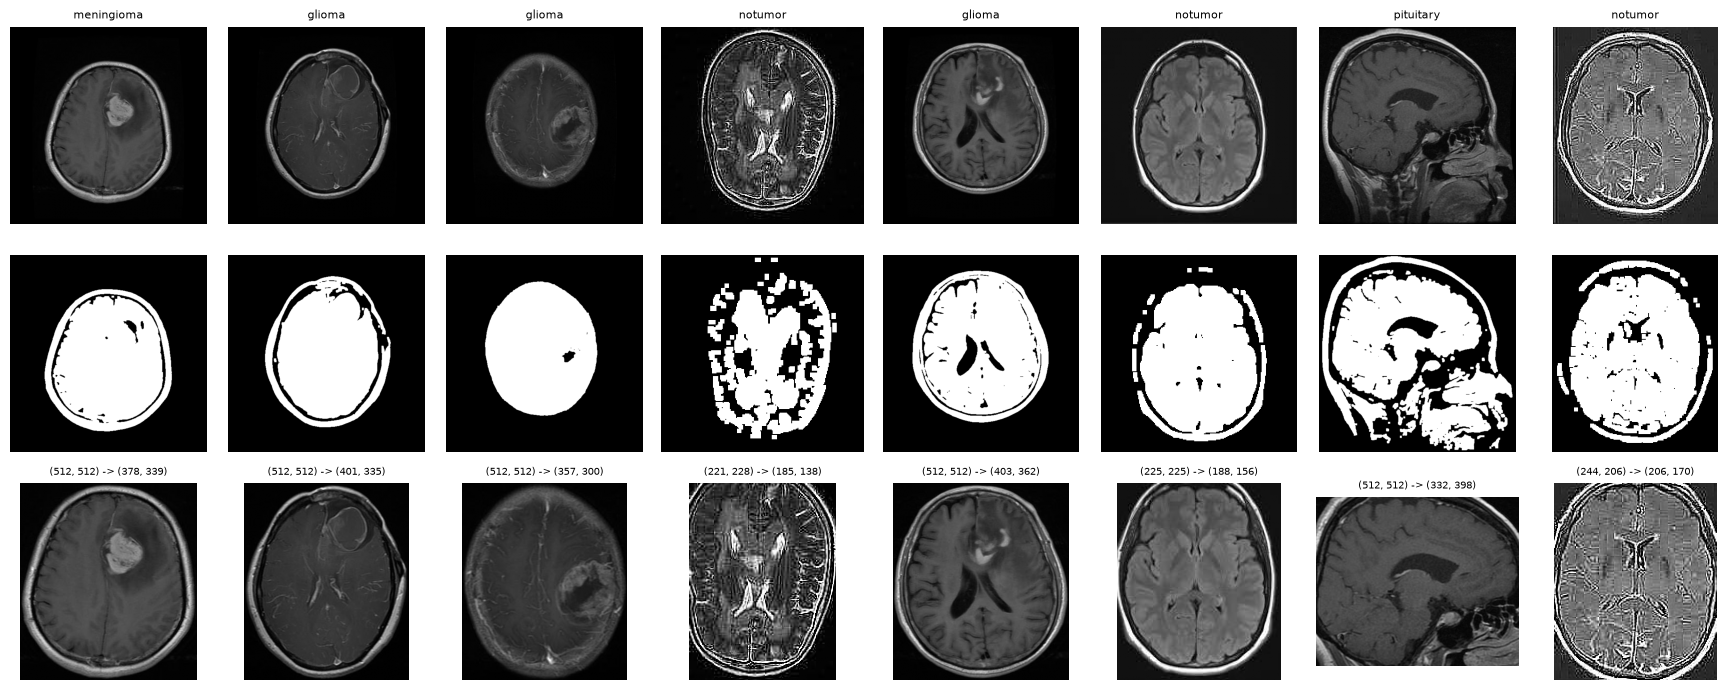

In [9]:
samples = random.sample(records, 8)

fig, axes = plt.subplots(3, len(samples), figsize=(2.2*len(samples), 7))
for j, (split, cls, p) in enumerate(samples):
    g = np.array(Image.open(p).convert("L"))
    cropped, mask = crop_margins(g, debug=True)

    axes[0, j].imshow(g, cmap="gray");       axes[0, j].set_title(cls, fontsize=8)
    axes[1, j].imshow(mask, cmap="gray")
    axes[2, j].imshow(cropped, cmap="gray")
    axes[2, j].set_title(f"{g.shape} -> {cropped.shape}", fontsize=7)
    for r in range(3):
        axes[r, j].axis("off")

axes[0, 0].set_ylabel("original"); axes[1, 0].set_ylabel("mask")
axes[2, 0].set_ylabel("cropped")
plt.tight_layout(); plt.show()

**Note:** Otsu might not be the best choice for this and so we might have to add a fixed basline value for thresholding. 

In [ ]:
# Quantify: how much area does cropping remove, per class?
# notumor should lose the most if its watermark bars and padding are going.

reductions = defaultdict(list)
for split, cls, p in random.sample(records, 400):
    g = np.array(Image.open(p).convert("L"))
    cropped = crop_margins(g)
    reductions[cls].append(1 - cropped.size / g.size)

for cls in CLASSES:
    r = np.array(reductions[cls])
    print(f"{cls:<14} median area removed: {100*np.median(r):>5.1f}%   "
          f"max: {100*r.max():>5.1f}%   failed (0%): {(r < 0.001).sum()}")

## 4. Pad to square, then resize

~20% of images are non-square. Stretching distorts anatomy and lets the model
learn aspect ratio as a shortcut. Padding preserves proportions at the cost of
some black border — which the crop already minimised.

In [ ]:
IMG_SIZE = 224   # matches what ImageNet-pretrained backbones expect

def pad_to_square(img, fill=0):
    """Pad the shorter side symmetrically so the result is square."""
    h, w = img.shape
    if h == w:
        return img
    size = max(h, w)
    top = (size - h) // 2
    left = (size - w) // 2
    out = np.full((size, size), fill, dtype=img.dtype)
    out[top:top+h, left:left+w] = img
    return out


def preprocess(path, size=IMG_SIZE):
    """Full pipeline for one image: load -> gray -> crop -> pad -> resize."""
    g = np.array(Image.open(path).convert("L"))   # handles RGB/RGBA/L uniformly
    g = crop_margins(g)
    g = pad_to_square(g)
    # INTER_AREA is the right interpolation for downsampling — it averages
    # over the source region instead of point-sampling, avoiding aliasing.
    return cv2.resize(g, (size, size), interpolation=cv2.INTER_AREA)

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for j, (split, cls, p) in enumerate(random.sample(records, 8)):
    axes[0, j].imshow(np.array(Image.open(p).convert("L")), cmap="gray")
    axes[0, j].set_title(cls, fontsize=8)
    axes[1, j].imshow(preprocess(p), cmap="gray")
    for r in range(2):
        axes[r, j].axis("off")
plt.tight_layout(); plt.show()

## 5. Cache to disk

Cropping is slow — running it once and reusing the result saves hours across
dozens of training runs. Written under `data/`, which is gitignored.

In [ ]:
OUT = Path("data/processed")
cache = {}

for i, (split, cls, p) in enumerate(records):
    arr = preprocess(p)
    d = OUT / split / cls
    d.mkdir(parents=True, exist_ok=True)
    np.save(d / f"{p.stem}.npy", arr)
    cache[p] = d / f"{p.stem}.npy"
    if (i + 1) % 1000 == 0:
        print(f"  {i+1} / {len(records)}")

print(f"Cached {len(cache)} images to {OUT.resolve()}")

## 6. Normalization statistics

Computed from the **training split only**. Using the full dataset leaks test
statistics into training.

If you fine-tune an ImageNet-pretrained backbone, use ImageNet's mean/std
instead — mismatched normalization quietly destroys transfer learning.

In [ ]:
train_arrs = [np.load(cache[p]) for s, c, p in records if s == "Training"]
stack = np.stack(train_arrs).astype(np.float32) / 255.0

MEAN, STD = float(stack.mean()), float(stack.std())
print(f"train mean: {MEAN:.4f}")
print(f"train std : {STD:.4f}")

with open("data/norm_stats.json", "w") as f:
    json.dump({"mean": MEAN, "std": STD, "size": IMG_SIZE}, f)

# Per-class means — if notumor sits far from the others, the pulse-sequence
# difference is still present after cropping (expected).
for cls in CLASSES:
    a = np.stack([np.load(cache[p]) for s, c, p in records
                  if s == "Training" and c == cls][:300]).astype(np.float32) / 255
    print(f"  {cls:<14} mean {a.mean():.4f}   std {a.std():.4f}")

## 7. Did cropping fix the leakage?

Re-run the two controls from notebook 01 on the **cropped** images. This is the
measurement that tells you whether margin removal did its job.

Expected: the border test collapses toward 0.262 (the background pixels are
gone). The 8×8 test stays elevated, because the `notumor` sequence difference
lives inside the brain and cropping cannot touch it.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

sub = random.sample(records, 2000)

# 8x8 test on cropped images
X8 = [cv2.resize(np.load(cache[p]), (8, 8),
                 interpolation=cv2.INTER_AREA).ravel() / 255.0
      for s, c, p in sub]
y = [c for s, c, p in sub]

Xtr, Xte, ytr, yte = train_test_split(X8, y, test_size=0.25,
                                      stratify=y, random_state=42)
acc8 = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

# Border-only test on cropped images
Xb = []
for s, c, p in sub:
    a = cv2.resize(np.load(cache[p]), (32, 32),
                   interpolation=cv2.INTER_AREA) / 255.0
    Xb.append(np.concatenate([a[:3].ravel(), a[-3:].ravel(),
                              a[3:-3, :3].ravel(), a[3:-3, -3:].ravel()]))

Xtr, Xte, ytr, yte = train_test_split(Xb, y, test_size=0.25,
                                      stratify=y, random_state=42)
accb = LogisticRegression(max_iter=2000).fit(Xtr, ytr).score(Xte, yte)

print(f"{'control':<28}{'before':>10}{'after':>10}")
print("-" * 48)
print(f"{'majority baseline':<28}{0.262:>10.3f}{0.262:>10.3f}")
print(f"{'8x8, no anatomy visible':<28}{0.650:>10.3f}{acc8:>10.3f}")
print(f"{'border pixels only':<28}{0.634:>10.3f}{accb:>10.3f}")

### How to read this

**Border test near 0.262** → cropping worked, the background shortcut is gone.

**Border test still high** → the crop isn't aggressive enough. Check the mask
visualisations in section 3 and consider tightening the threshold or increasing
the erode iterations.

**8×8 still high** → expected. That's the `notumor` pulse-sequence confound,
which no crop can remove. It's why the 3-class evaluation exists.

Record both numbers in `01_findings.md`, section 5.

## Next

`03_split.ipynb` — build the train/validation split using `GroupShuffleSplit`
with `data/train_groups.json`, so near-duplicate clusters stay on one side.